Run the first cell, reload(CTRL + R), then run the second cell

In [2]:
!wget https://github.com/korakot/kora/releases/download/v0.10/py310.sh
!bash ./py310.sh -b -f -p /usr/local
!python -m ipykernel install --name "py310" --user

--2026-03-16 06:26:49--  https://github.com/korakot/kora/releases/download/v0.10/py310.sh
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/266951884/0d0623be-3dec-4820-9e7b-69a3a5a75ef7?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-16T07%3A14%3A36Z&rscd=attachment%3B+filename%3Dpy310.sh&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-16T06%3A13%3A50Z&ske=2026-03-16T07%3A14%3A36Z&sks=b&skv=2018-11-09&sig=YSgJ8sKQhdDnGdUtfydDBlDqazB95pH5KDIDMyQaDHw%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MzY0NjAwOSwibmJmIjoxNzczNjQyNDA5LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmUud2luZG93cy5u

In [1]:
!pip uninstall -y numpy scipy scikit-learn lightfm
!pip install numpy==1.23.5
!pip install scipy==1.10.1
!pip install scikit-learn==1.3.2
!pip install lightfm --no-cache-dir


Found existing installation: numpy 1.23.4
Uninstalling numpy-1.23.4:
  Successfully uninstalled numpy-1.23.4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 37.2 MB/s eta 0:00:00


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 44.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 55.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 39.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.4/316.4 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lightfm: filename=lightfm-1.17-cp310-cp310-linux_x86_64.whl size=448993 sha256=badd16fbf46ce9f7f22d679d3596efd7362c03c725751979603db9a16d8f5c55
  Stored in directory: /tmp/pip-ephem-wheel-cache-sz6sz4oa/wheels/86/ac/94/30f4b2d4af04cae5d95391037229ac082aa87aab0ccd660c96
Successfully built lightfm


In [2]:
import pandas as pd
import numpy as np
import pickle
from lightfm import LightFM
from lightfm.data import Dataset
from lightfm.evaluation import auc_score, precision_at_k
from lightfm.cross_validation import random_train_test_split

# ── 1. CHARGEMENT DES DONNÉES ────────────────────────────────────────────────
t_df = pd.read_csv("trajets.csv")
d_df = pd.read_csv("drivers.csv")
i_df = pd.read_csv("interactions.csv")

print(f"📊 Trajets    : {len(t_df)}")
print(f"📊 Drivers    : {len(d_df)}")
print(f"📊 Interactions: {len(i_df)}")

# ── 2. NETTOYAGE DES NAN ─────────────────────────────────────────────────────
yes_no_cols = [
    "quiet_ride", "radio_ok", "smoking_ok", "pets_ok",
    "luggage_large", "female_driver_pref",
    "talkative", "radio_on", "smoking_allowed", "pets_allowed",
    "car_big", "works_morning", "works_afternoon", "works_evening", "works_night"
]
for col in yes_no_cols:
    if col in t_df.columns:
        t_df[col] = t_df[col].fillna("no")
    if col in d_df.columns:
        d_df[col] = d_df[col].fillna("no")

t_df["distance_km"]     = pd.to_numeric(t_df["distance_km"],     errors="coerce").fillna(50.0)
t_df["score_distance"]  = pd.to_numeric(t_df["score_distance"],  errors="coerce").fillna(0.5)
t_df["work_hour_match"] = pd.to_numeric(t_df["work_hour_match"], errors="coerce").fillna(0)
d_df["avg_rating"]      = pd.to_numeric(d_df["avg_rating"],      errors="coerce").fillna(4.0)

def distance_bucket(km):
    if   km < 10:  return "dist:very_close"
    elif km < 30:  return "dist:close"
    elif km < 80:  return "dist:medium"
    elif km < 200: return "dist:far"
    else:          return "dist:very_far"

def rating_bucket(r):
    if   r >= 4.5: return "rating:excellent"
    elif r >= 4.0: return "rating:good"
    elif r >= 3.0: return "rating:average"
    else:          return "rating:poor"

t_df["distance_bucket"] = t_df["distance_km"].apply(distance_bucket)
d_df["rating_bucket"]   = d_df["avg_rating"].apply(rating_bucket)

# ── 3. CONFIGURATION DU DATASET ──────────────────────────────────────────────
dataset = Dataset()

user_features_list = [
    "quiet_ride:yes",          "quiet_ride:no",
    "radio_ok:yes",            "radio_ok:no",
    "smoking_ok:yes",          "smoking_ok:no",
    "pets_ok:yes",             "pets_ok:no",
    "luggage_large:yes",       "luggage_large:no",
    "female_driver_pref:yes",  "female_driver_pref:no",
    "dist:very_close", "dist:close", "dist:medium", "dist:far", "dist:very_far",
    "work_hour_match:1", "work_hour_match:0",
]

item_features_list = [
    "talkative:yes",           "talkative:no",
    "radio_on:yes",            "radio_on:no",
    "smoking_allowed:yes",     "smoking_allowed:no",
    "pets_allowed:yes",        "pets_allowed:no",
    "car_big:yes",             "car_big:no",
    "driver_gender:male",      "driver_gender:female",
    "works_morning:yes",       "works_morning:no",
    "works_afternoon:yes",     "works_afternoon:no",
    "works_evening:yes",       "works_evening:no",
    "works_night:yes",         "works_night:no",
    "rating:excellent", "rating:good", "rating:average", "rating:poor",
]

dataset.fit(
    users=t_df["trajet_id"].unique(),
    items=d_df["driver_id"].unique(),
    user_features=user_features_list,
    item_features=item_features_list
)

# ── 4. CONSTRUCTION DES MATRICES ─────────────────────────────────────────────
good_interactions = i_df[i_df["weight"] > 0.3]
print(f"\n📊 Interactions utilisées (weight > 0.3) : {len(good_interactions)}/{len(i_df)}")

(interactions, weights) = dataset.build_interactions(
    [
        (row["trajet_id"], row["driver_id"], row["weight"])
        for _, row in good_interactions.iterrows()
    ]
)

# ✅ user_features et item_features construits ICI avant tout le reste
user_features = dataset.build_user_features(
    [
        (
            row["trajet_id"],
            [
                f"quiet_ride:{row['quiet_ride']}",
                f"radio_ok:{row['radio_ok']}",
                f"smoking_ok:{row['smoking_ok']}",
                f"pets_ok:{row['pets_ok']}",
                f"luggage_large:{row['luggage_large']}",
                f"female_driver_pref:{row['female_driver_pref']}",
                row["distance_bucket"],
                f"work_hour_match:{int(row['work_hour_match'])}",
            ],
        )
        for _, row in t_df.iterrows()
    ]
)

item_features = dataset.build_item_features(
    [
        (
            row["driver_id"],
            [
                f"talkative:{row['talkative']}",
                f"radio_on:{row['radio_on']}",
                f"smoking_allowed:{row['smoking_allowed']}",
                f"pets_allowed:{row['pets_allowed']}",
                f"car_big:{row['car_big']}",
                f"driver_gender:{row['driver_gender']}",
                f"works_morning:{row['works_morning']}",
                f"works_afternoon:{row['works_afternoon']}",
                f"works_evening:{row['works_evening']}",
                f"works_night:{row['works_night']}",
                row["rating_bucket"],
            ],
        )
        for _, row in d_df.iterrows()
    ]
)

print(f"✅ user_features et item_features construits")

# ── 5. TRAIN/TEST SPLIT ───────────────────────────────────────────────────────
train_interactions, test_interactions = random_train_test_split(
    interactions,
    test_percentage=0.2,
    random_state=42
)
print(f"\n📊 Train interactions : {train_interactions.nnz}")
print(f"📊 Test interactions  : {test_interactions.nnz}")

# ── 6. BASELINE ───────────────────────────────────────────────────────────────
print("\n🔁 Entraînement baseline...")
baseline = LightFM(loss="warp", no_components=1, random_state=42)
baseline.fit(
    train_interactions,
    item_features=item_features,
    epochs=10
)
baseline_auc = auc_score(
    baseline, test_interactions,
    train_interactions=train_interactions,
    item_features=item_features
).mean()
baseline_p5 = precision_at_k(
    baseline, test_interactions,
    train_interactions=train_interactions,
    item_features=item_features,
    k=5
).mean()
print(f"   Baseline AUC        : {baseline_auc:.4f}")
print(f"   Baseline Precision@5: {baseline_p5:.4f}")

# ── 7. ENTRAÎNEMENT MODÈLE PRINCIPAL ─────────────────────────────────────────
model = LightFM(
    loss="warp",
    no_components=50,
    learning_rate=0.03,
    random_state=42
)

n_interactions = train_interactions.nnz

if   n_interactions < 100:    epochs = 10
elif n_interactions < 500:    epochs = 60
elif n_interactions < 2000:   epochs = 120
elif n_interactions < 5000:   epochs = 200
elif n_interactions < 10000:  epochs = 230
else:                         epochs = 250

print(f"\n📊 {n_interactions} interactions train → {epochs} epochs")
print("\n🚀 Démarrage de l'entraînement...")

for epoch in range(1, epochs + 1):
    model.fit_partial(
        train_interactions,
        user_features=user_features,
        item_features=item_features,
        epochs=1
    )
    if epoch % 10 == 0:
        current_auc = auc_score(
            model, train_interactions,
            user_features=user_features,
            item_features=item_features
        ).mean()
        print(f"   Époque {epoch:3d} | AUC train: {current_auc:.4f}")

# ── 8. ÉVALUATION FINALE SUR TEST ────────────────────────────────────────────
print("\n📈 Évaluation finale sur données test...")

final_auc = auc_score(
    model, test_interactions,
    train_interactions=train_interactions,
    user_features=user_features,
    item_features=item_features
).mean()

final_p5 = precision_at_k(
    model, test_interactions,
    train_interactions=train_interactions,
    user_features=user_features,
    item_features=item_features,
    k=5
).mean()

print(f"\n{'='*40}")
print(f"  RÉSULTATS FINAUX")
print(f"{'='*40}")
print(f"  Baseline     — AUC: {baseline_auc:.4f} | Precision@5: {baseline_p5:.4f}")
print(f"  Notre modèle — AUC: {final_auc:.4f} | Precision@5: {final_p5:.4f}")
print(f"  Gain AUC        : +{(final_auc - baseline_auc):.4f}")
print(f"  Gain Precision@5: +{(final_p5 - baseline_p5):.4f}")
print(f"{'='*40}")

# ── 9. SAUVEGARDE ────────────────────────────────────────────────────────────
with open("lightfm_model_real.pkl", "wb") as f:
    pickle.dump(model, f)
with open("dataset_real.pkl", "wb") as f:
    pickle.dump(dataset, f)
with open("user_features_real.pkl", "wb") as f:
    pickle.dump(user_features, f)
with open("item_features_real.pkl", "wb") as f:
    pickle.dump(item_features, f)

t_df.to_csv("trajets_processed.csv", index=False)
d_df.to_csv("drivers_processed.csv", index=False)

print("\n✅ Tout sauvegardé !")

📊 Trajets    : 2921
📊 Drivers    : 190
📊 Interactions: 2921

📊 Interactions utilisées (weight > 0.3) : 292/2921
✅ user_features et item_features construits

📊 Train interactions : 233
📊 Test interactions  : 59

🔁 Entraînement baseline...
   Baseline AUC        : 0.6995
   Baseline Precision@5: 0.0305

📊 233 interactions train → 60 epochs

🚀 Démarrage de l'entraînement...
   Époque  10 | AUC train: 0.7284
   Époque  20 | AUC train: 0.8371
   Époque  30 | AUC train: 0.8853
   Époque  40 | AUC train: 0.8864
   Époque  50 | AUC train: 0.8918
   Époque  60 | AUC train: 0.8965

📈 Évaluation finale sur données test...

  RÉSULTATS FINAUX
  Baseline     — AUC: 0.6995 | Precision@5: 0.0305
  Notre modèle — AUC: 0.8779 | Precision@5: 0.0373
  Gain AUC        : +0.1785
  Gain Precision@5: +0.0068

✅ Tout sauvegardé !


In [4]:
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 35.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 81.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 86.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 15.6 MB/s eta 0:00:00


   20% data (58 interactions) → AUC: 0.7200
   40% data (116 interactions) → AUC: 0.7802
   60% data (175 interactions) → AUC: 0.8203
   80% data (233 interactions) → AUC: 0.8145
   100% data (292 interactions) → AUC: 0.8549


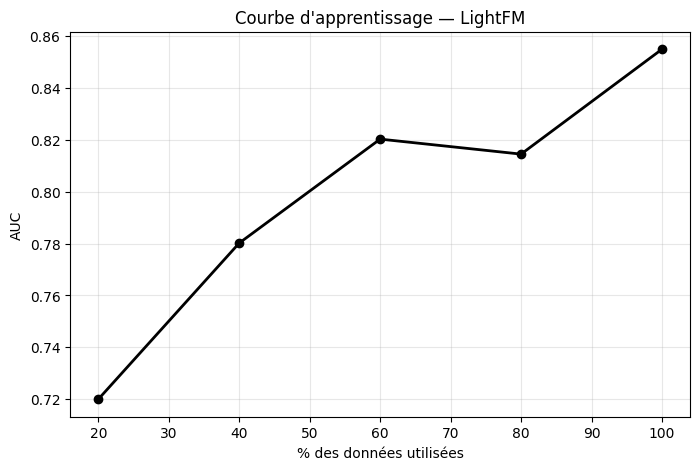

In [5]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Tester avec différentes tailles de données
sizes = [0.2, 0.4, 0.6, 0.8, 1.0]
auc_scores = []

for size in sizes:
    # Prendre un subset des interactions
    subset_size = int(len(good_interactions) * size)
    subset = good_interactions.sample(n=subset_size, random_state=42)

    (sub_interactions, _) = dataset.build_interactions(
        [(row["trajet_id"], row["driver_id"], row["weight"])
         for _, row in subset.iterrows()]
    )

    train_sub, test_sub = random_train_test_split(
        sub_interactions, test_percentage=0.2, random_state=42
    )

    temp_model = LightFM(loss="warp", no_components=50,
                         learning_rate=0.03, random_state=42)
    temp_model.fit(
        train_sub,
        user_features=user_features,
        item_features=item_features,
        epochs=60
    )

    auc = auc_score(
        temp_model, test_sub,
        train_interactions=train_sub,
        user_features=user_features,
        item_features=item_features
    ).mean()

    auc_scores.append(auc)
    print(f"   {int(size*100)}% data ({subset_size} interactions) → AUC: {auc:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot([int(s*100) for s in sizes], auc_scores,
         marker='o', color='black', linewidth=2)
plt.xlabel("% des données utilisées")
plt.ylabel("AUC")
plt.title("Courbe d'apprentissage — LightFM")
plt.grid(True, alpha=0.3)
plt.savefig("learning_curve.png", dpi=150, bbox_inches='tight')
plt.show()